<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/UFC_2025_Dataset_Fights%2C_Fighters_%26_Events_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d aminealibi/ufc-fights-fighters-and-events-dataset

# Unziping the downloaded file
!unzip ufc-fights-fighters-and-events-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aminealibi/ufc-fights-fighters-and-events-dataset
License(s): CC0-1.0
  0% 0.00/2.73M [00:00<?, ?B/s]
100% 2.73M/2.73M [00:00<00:00, 739MB/s]
Archive:  ufc-fights-fighters-and-events-dataset.zip
  inflating: data/Events.csv         
  inflating: data/Fighters Stats.csv  
  inflating: data/Fighters.csv       
  inflating: data/Fights.csv         
  inflating: raw_data/raw_details.csv  
  inflating: raw_data/raw_events.csv  
  inflating: raw_data/raw_fighters.csv  
  inflating: raw_data/raw_fights.csv  
  inflating: raw_data/raw_fights_detailed.csv  


In [14]:
df = pd.read_csv('raw_data/raw_details.csv')
df.head()

,Fight_Id,Result_1,Result_2,Time Format,Referee,Method Details,Kd_1,Kd_2,Sig. Str._1,Sig. Str._2,...,Body_2,Leg_1,Leg_2,Distance_1,Distance_2,Clinch_1,Clinch_2,Ground_1,Ground_2,Event_Id
0,de1a3734be60e6a1,W,L,5 Rnd (5-5-5-5-5),Mike Beltran,Punches to Head On Ground,1.0,0.0,74 of 135,43 of 91,...,10 of 17,10 of 16,7 of 7,31 of 65,42 of 90,1 of 2,1 of 1,42 of 68,0 of 0,5efaaf313b652dd7
1,944b929130b23c2a,L,W,3 Rnd (5-5-5),Dan Miragliotta,Chris Lee28 - 29.Sal D'amato28 - 29.Junichiro ...,0.0,0.0,49 of 158,62 of 155,...,10 of 16,2 of 3,19 of 24,49 of 158,62 of 155,0 of 0,0 of 0,0 of 0,0 of 0,5efaaf313b652dd7
2,7cbfeba85f86d1bf,W,L,3 Rnd (5-5-5),Kerry Hatley,Elbows to Head From Side Control,1.0,0.0,91 of 162,65 of 186,...,8 of 13,10 of 11,2 of 2,70 of 137,65 of 186,10 of 11,0 of 0,11 of 14,0 of 0,5efaaf313b652dd7
3,114d2f6fcd3f6f00,W,L,3 Rnd (5-5-5),Jacob Montalvo,Chris Lee27 - 30.Jeff Rexroad28 - 29.Junichiro...,1.0,0.0,57 of 117,64 of 146,...,25 of 34,11 of 12,14 of 19,56 of 116,55 of 134,1 of 1,4 of 5,0 of 0,5 of 7,5efaaf313b652dd7
4,202c47db69768356,W,L,3 Rnd (5-5-5),Jeff Rexroad,Punches to Head On Ground,1.0,0.0,30 of 75,23 of 98,...,11 of 35,4 of 6,4 of 7,20 of 61,23 of 96,0 of 0,0 of 2,10 of 14,0 of 0,5efaaf313b652dd7


In [15]:
df.tail(11)

,Fight_Id,Result_1,Result_2,Time Format,Referee,Method Details,Kd_1,Kd_2,Sig. Str._1,Sig. Str._2,...,Body_2,Leg_1,Leg_2,Distance_1,Distance_2,Clinch_1,Clinch_2,Ground_1,Ground_2,Event_Id
8340,c4aa04781989699e,W,L,No Time Limit,John McCarthy,Elbows to Head From Side Control,0.0,0.0,7 of 7,1 of 2,...,0 of 0,0 of 0,1 of 1,0 of 0,1 of 2,0 of 0,0 of 0,7 of 7,0 of 0,a6a9ab5a824e8f66
8341,b72acedda7ddc006,W,L,No Time Limit,John McCarthy,Bulldog Choke On Ground,1.0,0.0,13 of 29,4 of 7,...,2 of 4,1 of 1,2 of 2,3 of 6,4 of 7,1 of 2,0 of 0,9 of 21,0 of 0,a6a9ab5a824e8f66
8342,8ea72cf82fac07f6,W,L,No Time Limit,John McCarthy,Elbows to Head From Mount,0.0,0.0,13 of 17,0 of 0,...,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0,1 of 1,0 of 0,12 of 16,0 of 0,a6a9ab5a824e8f66
8343,fcd8e8ec45eb6b9f,W,L,No Time Limit,John McCarthy,Armbar On Ground,0.0,0.0,2 of 4,3 of 7,...,0 of 0,2 of 4,0 of 1,2 of 4,0 of 2,0 of 0,0 of 0,0 of 0,3 of 5,a6a9ab5a824e8f66
8344,c53325be8ce33b8b,W,L,No Time Limit,John McCarthy,Triangle Choke From Mount,0.0,0.0,3 of 5,0 of 2,...,0 of 0,1 of 1,0 of 0,2 of 4,0 of 2,0 of 0,0 of 0,1 of 1,0 of 0,a6a9ab5a824e8f66
8345,17ee4caf06981b81,W,L,No Time Limit,John McCarthy,Ezekiel Choke From Side Control,0.0,0.0,4 of 6,1 of 3,...,0 of 0,0 of 1,0 of 0,0 of 1,1 of 1,0 of 0,0 of 0,4 of 5,0 of 2,a6a9ab5a824e8f66
8346,3b020d4914b44fc8,W,L,No Time Limit,John McCarthy,to \n Corner Stoppage,0.0,0.0,8 of 12,2 of 6,...,0 of 1,0 of 0,1 of 3,1 of 3,2 of 6,0 of 0,0 of 0,7 of 9,0 of 0,a6a9ab5a824e8f66
8347,d917c8c7461b9831,W,L,No Time Limit,John McCarthy,Keylock From Half Guard,0.0,0.0,2 of 3,0 of 0,...,0 of 0,0 of 0,0 of 0,1 of 1,0 of 0,0 of 0,0 of 0,1 of 2,0 of 0,a6a9ab5a824e8f66
8348,ccee020be2e8d9f6,W,L,No Time Limit,John McCarthy,Punches to Head From Guard\n Submission t...,0.0,0.0,11 of 17,4 of 5,...,0 of 0,1 of 1,0 of 0,1 of 1,1 of 2,1 of 1,2 of 2,9 of 15,1 of 1,a6a9ab5a824e8f66
8349,4b9ae533ccb3fcdf,W,L,No Time Limit,John McCarthy,Guillotine Choke Standing,0.0,0.0,1 of 1,1 of 1,...,0 of 0,0 of 0,1 of 1,0 of 0,1 of 1,1 of 1,0 of 0,0 of 0,0 of 0,a6a9ab5a824e8f66


In [16]:
df.shape

(8351, 37)

In [24]:
dff = all_data.iloc[:, :10]

# Displaying the head of the dataframe with selected columns
dff.head(11)

,Event_Id,Name,Date,Location,Full Name,Nickname,Ht.,Wt.,Reach,Stance
0,5efaaf313b652dd7,UFC Fight Night: Lopes vs. Silva,2025-09-13,"San Antonio, Texas, USA",NaN,NaN,NaN,NaN,NaN,NaN
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",NaN,NaN,NaN,NaN,NaN,NaN
2,754968e325d6f60d,UFC Fight Night: Walker vs. Zhang,2025-08-23,"Shanghai, Hebei, China",NaN,NaN,NaN,NaN,NaN,NaN
3,421ccfc6ddb17958,UFC 319: Du Plessis vs. Chimaev,2025-08-16,"Chicago, Illinois, USA",NaN,NaN,NaN,NaN,NaN,NaN
4,6cd3dfc54f01287f,UFC Fight Night: Dolidze vs. Hernandez,2025-08-09,"Las Vegas, Nevada, USA",NaN,NaN,NaN,NaN,NaN,NaN
5,f2c934689243fe4e,UFC Fight Night: Taira vs. Park,2025-08-02,"Las Vegas, Nevada, USA",NaN,NaN,NaN,NaN,NaN,NaN
6,28d8638ea0a71908,UFC Fight Night: Whittaker vs. De Ridder,2025-07-26,"Abu Dhabi, Abu Dhabi, United Arab Emirates",NaN,NaN,NaN,NaN,NaN,NaN
7,b8e2f10efb6eca85,UFC 318: Holloway vs. Poirier 3,2025-07-19,"New Orleans, Louisiana, USA",NaN,NaN,NaN,NaN,NaN,NaN
8,7b03d9df5910917d,UFC Fight Night: Lewis vs. Teixeira,2025-07-12,"Nashville, Tennessee, USA",NaN,NaN,NaN,NaN,NaN,NaN
9,66766984842c13dc,UFC 317: Topuria vs. Oliveira,2025-06-28,"Las Vegas, Nevada, USA",NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
dff.shape

(13519, 10)

In [26]:
dff.columns

Index(['Event_Id', 'Name', 'Date', 'Location', 'Full Name', 'Nickname', 'Ht.',
       'Wt.', 'Reach', 'Stance'],
      dtype='object')

In [27]:
dff.dtypes

,0
Event_Id,object
Name,object
Date,object
Location,object
Full Name,object
Nickname,object
Ht.,float64
Wt.,float64
Reach,float64
Stance,object


In [28]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13519 entries, 0 to 13518
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Event_Id   9076 non-null   object 
 1   Name       746 non-null    object 
 2   Date       746 non-null    object 
 3   Location   746 non-null    object 
 4   Full Name  4443 non-null   object 
 5   Nickname   4443 non-null   object 
 6   Ht.        4089 non-null   float64
 7   Wt.        4357 non-null   float64
 8   Reach      2467 non-null   float64
 9   Stance     4443 non-null   object 
dtypes: float64(3), object(7)
memory usage: 1.0+ MB


In [29]:
dff.describe(include = 'all')

,Event_Id,Name,Date,Location,Full Name,Nickname,Ht.,Wt.,Reach,Stance
count,9076,746,746,746,4443,4443,4089.000000,4357.000000,2467.000000,4443
unique,746,746,741,172,4436,1940,NaN,NaN,NaN,5
top,a6a9ab5a824e8f66,UFC 2: No Way Out,2016-11-19,"Las Vegas, Nevada, USA",Jean Silva,No Nickname,NaN,NaN,NaN,Orthodox
freq,16,1,2,258,2,1978,NaN,NaN,NaN,3610
mean,NaN,NaN,NaN,NaN,NaN,NaN,5.754566,170.044297,71.537900,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.420595,39.597511,4.261105,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,4.700000,105.000000,58.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,5.400000,145.000000,69.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,5.800000,160.000000,72.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,6.100000,185.000000,75.000000,NaN


In [30]:
dff.isnull().sum()

,0
Event_Id,4443
Name,12773
Date,12773
Location,12773
Full Name,9076
Nickname,9076
Ht.,9430
Wt.,9162
Reach,11052
Stance,9076


# Hanlding Missing Values

In [33]:
# Identify numerical and categorical columns
numerical_cols = dff.select_dtypes(include=np.number).columns
categorical_cols = dff.select_dtypes(include='object').columns

# For numerical columns, we might impute with the mean or median
for col in numerical_cols:
    if dff[col].isnull().any():
        dff[col].fillna(dff[col].mean(), inplace=True)

# For categorical columns, we might impute with the mode or a constant
for col in categorical_cols:
    if dff[col].isnull().any():
        dff[col].fillna(dff[col].mode()[0], inplace=True)

print("\nMissing values after handling:")
dff.isnull().sum()


Missing values after handling:


,0
Event_Id,0
Name,0
Date,0
Location,0
Full Name,0
Nickname,0
Ht.,0
Wt.,0
Reach,0
Stance,0


In [34]:
dff.duplicated().sum()

np.int64(7584)

# Handling Duplicated Values

In [37]:
dff.drop_duplicates(inplace=True)

dff.duplicated().sum()

np.int64(0)

# Handling Outliers

In [39]:
Q1 = dff['Reach'].quantile(0.25)
Q3 = dff['Reach'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = dff[(dff['Reach'] >= lower_bound) | (dff['Reach'] <= upper_bound)].copy()

print(f'Original Shape: {len(dff)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 5935
Shape after outlier handling: 5935


# Univariate Analysis

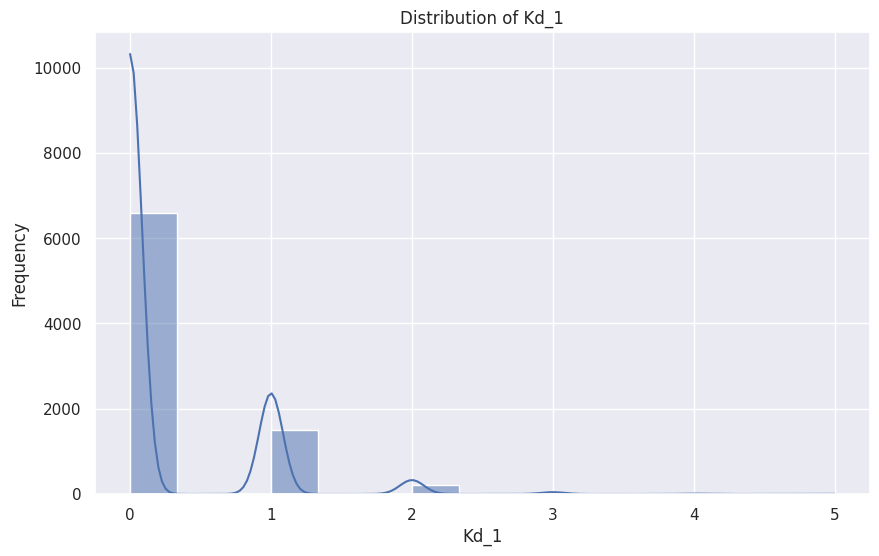

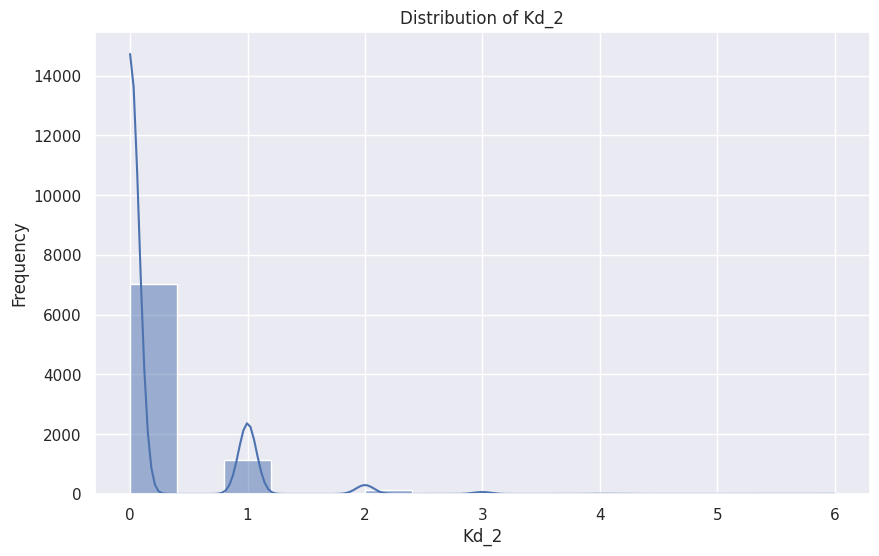

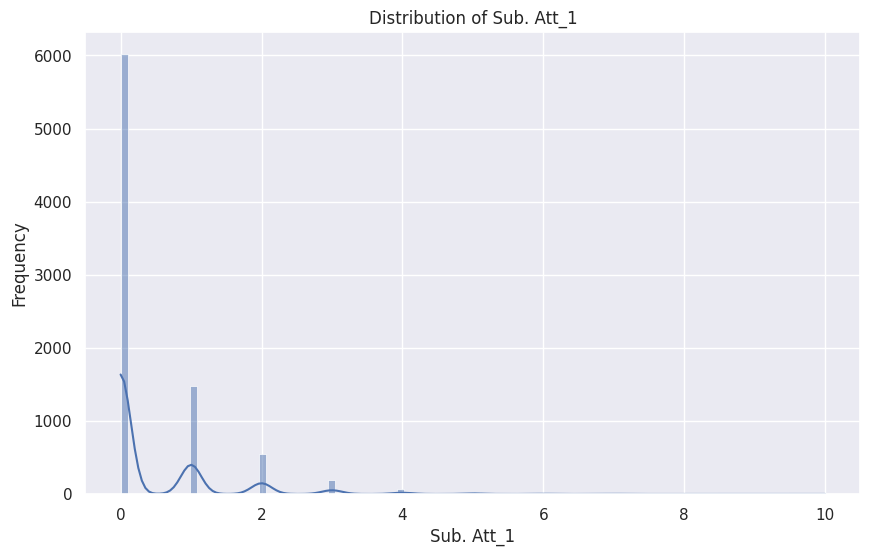

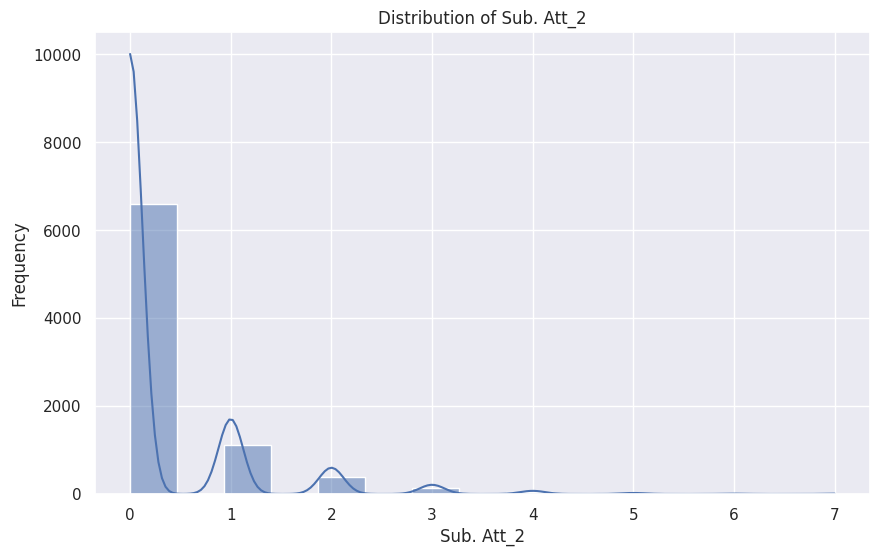

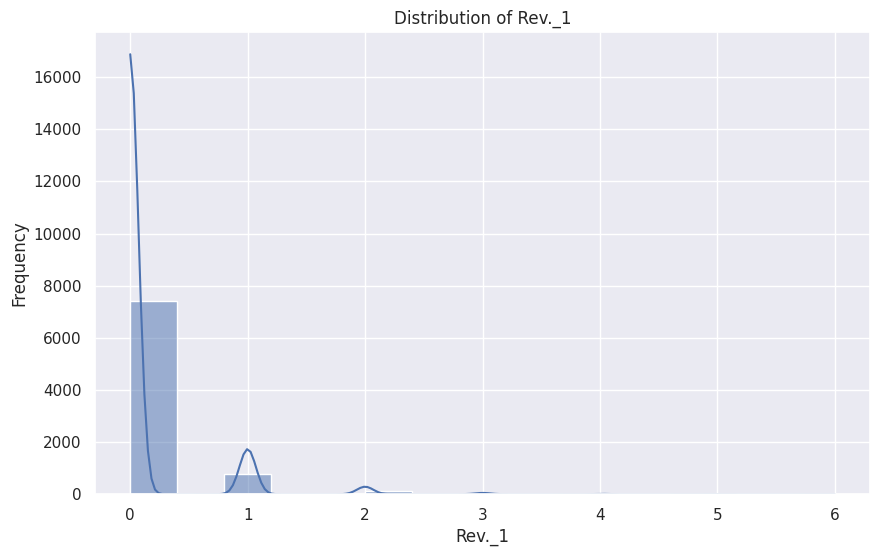

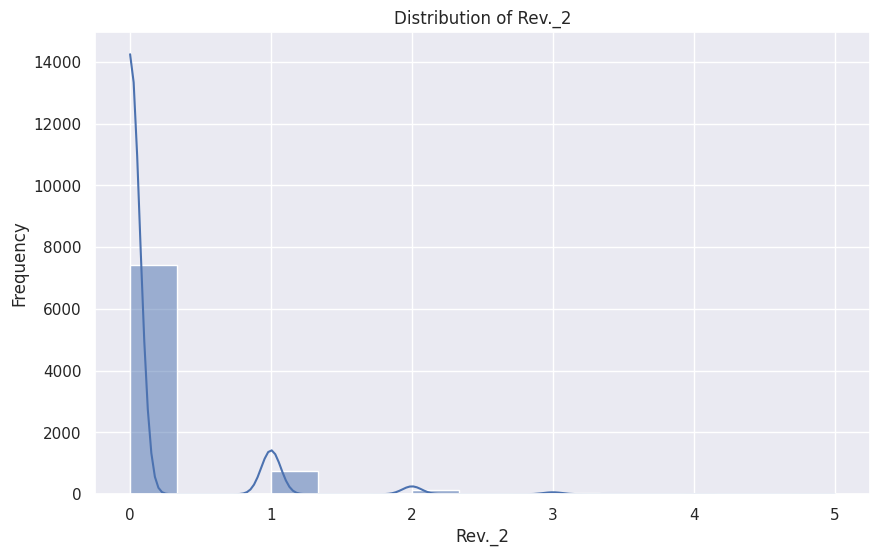

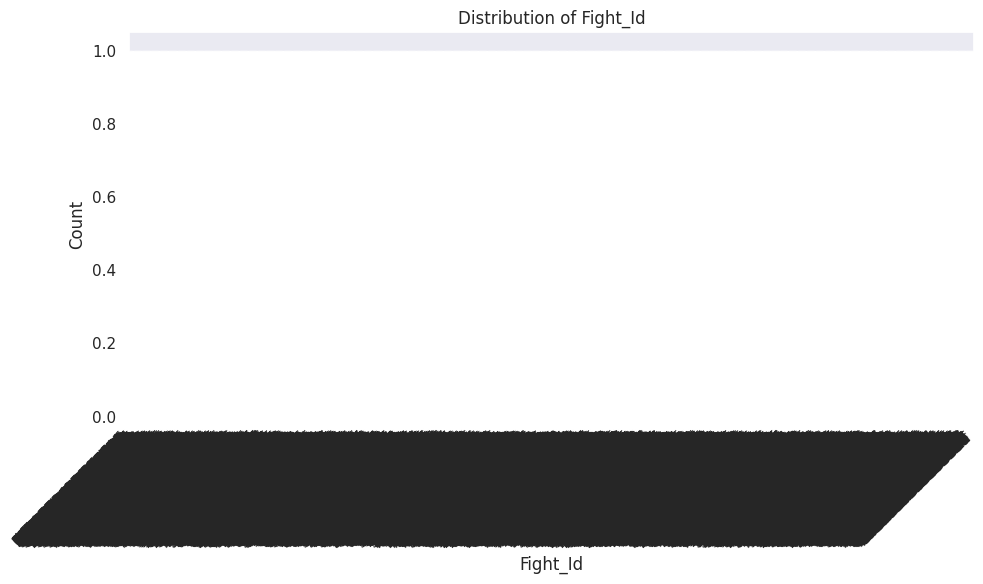

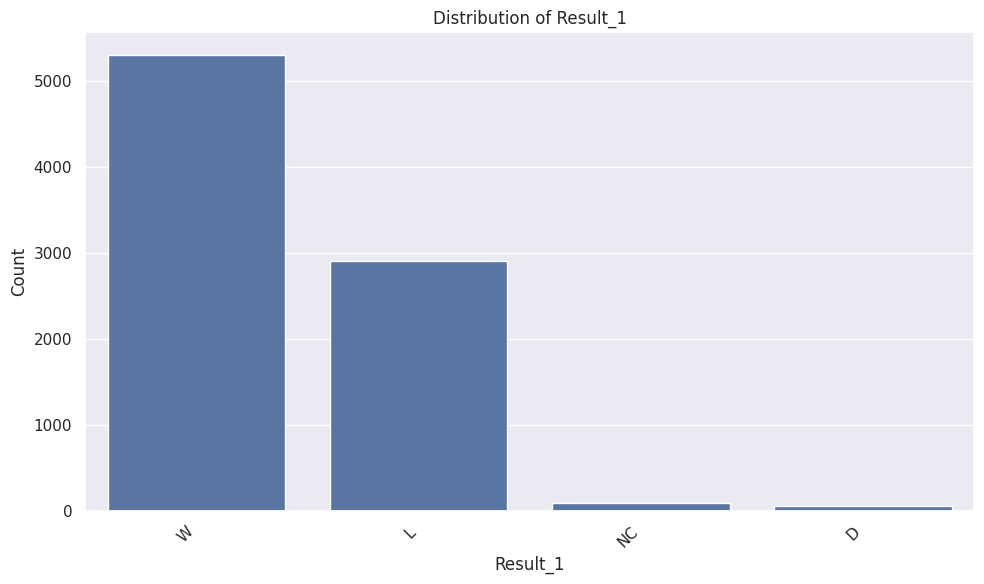

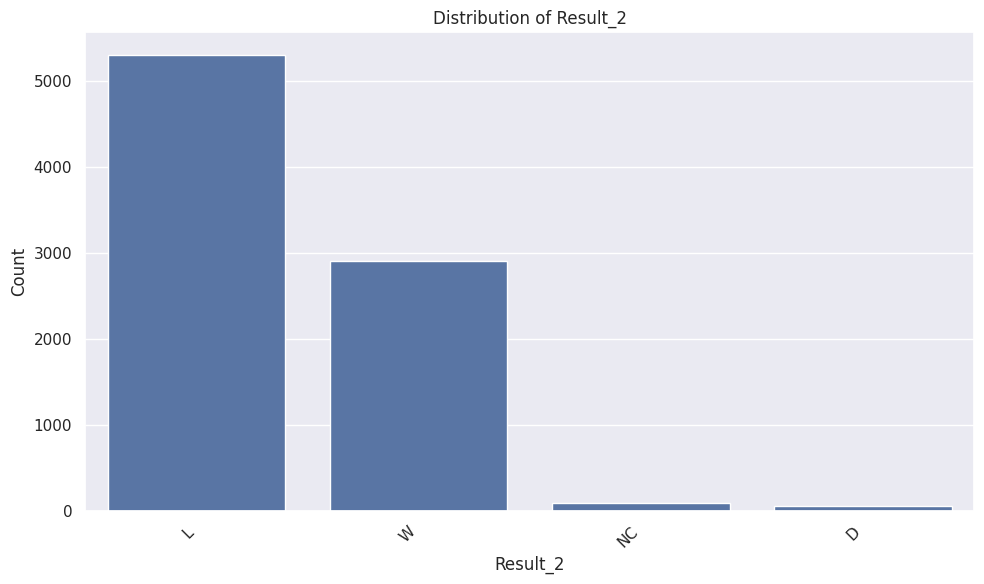

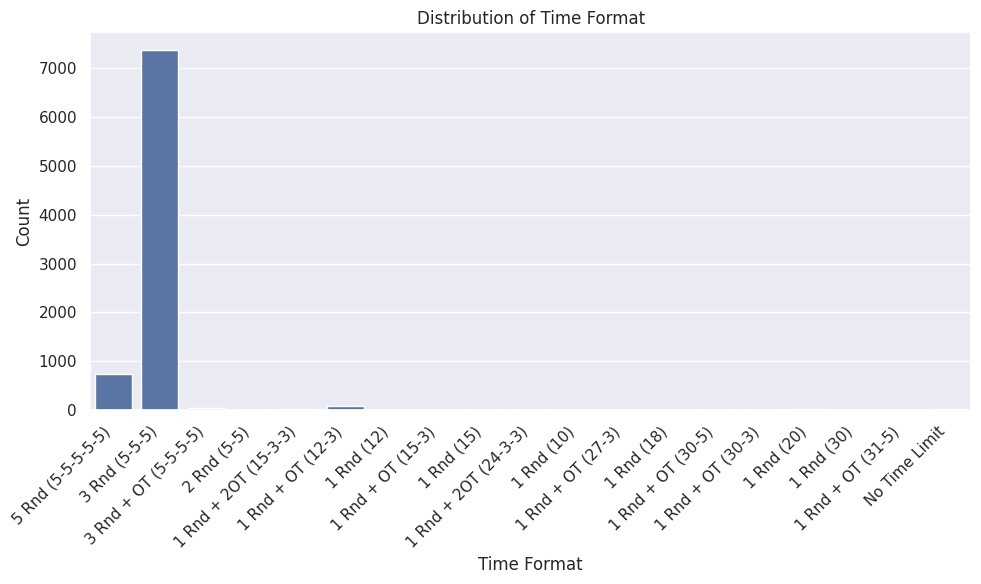

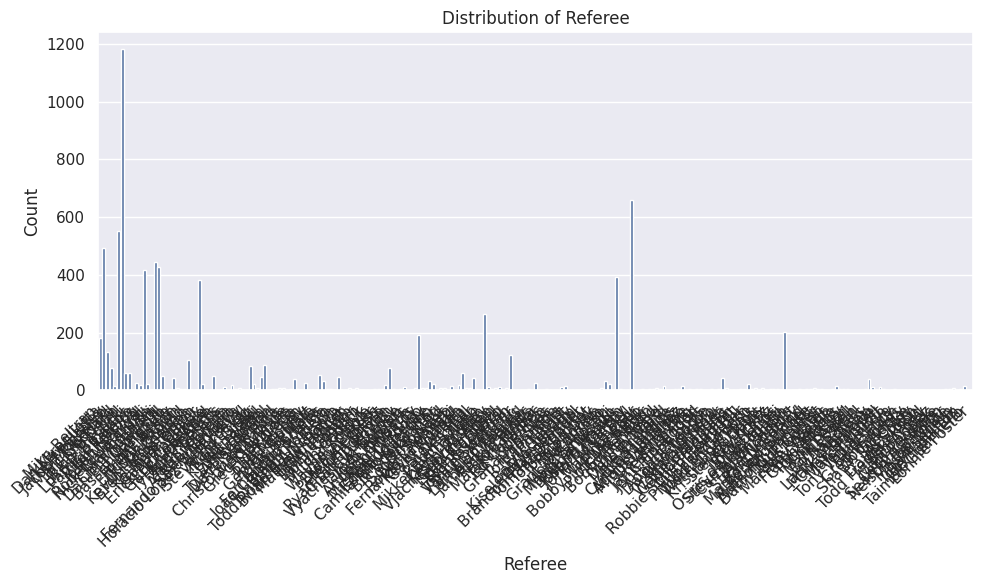

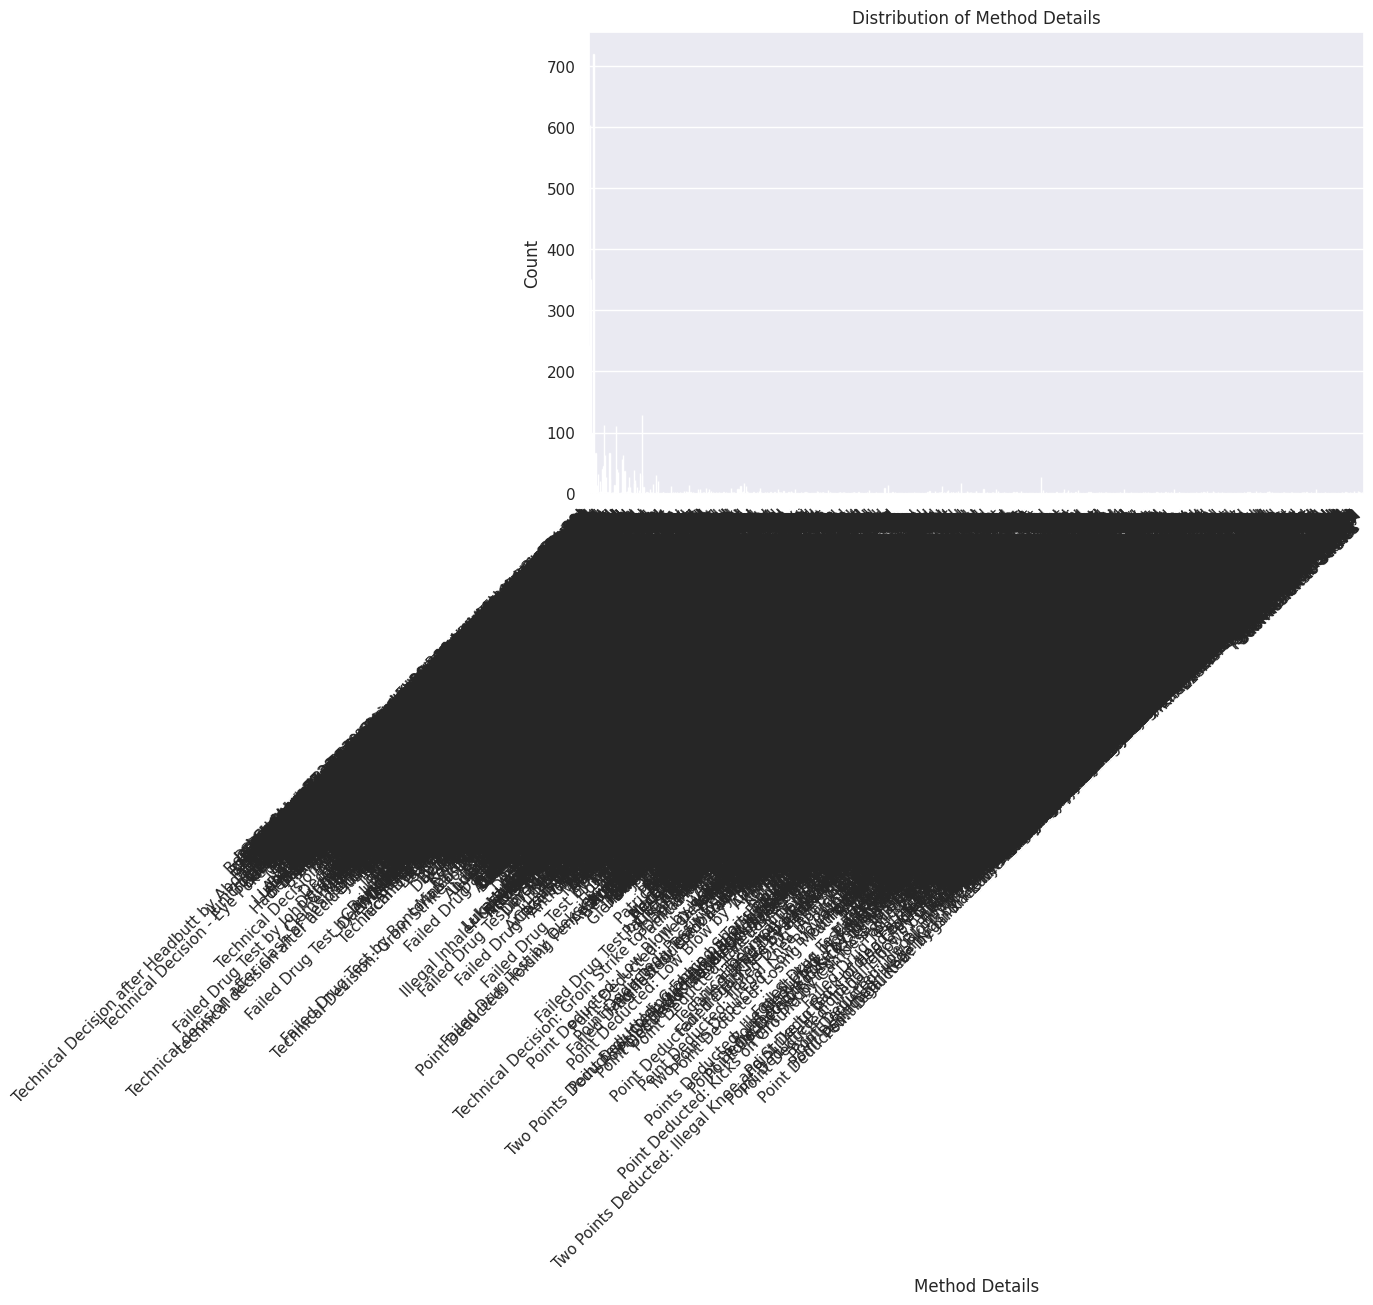

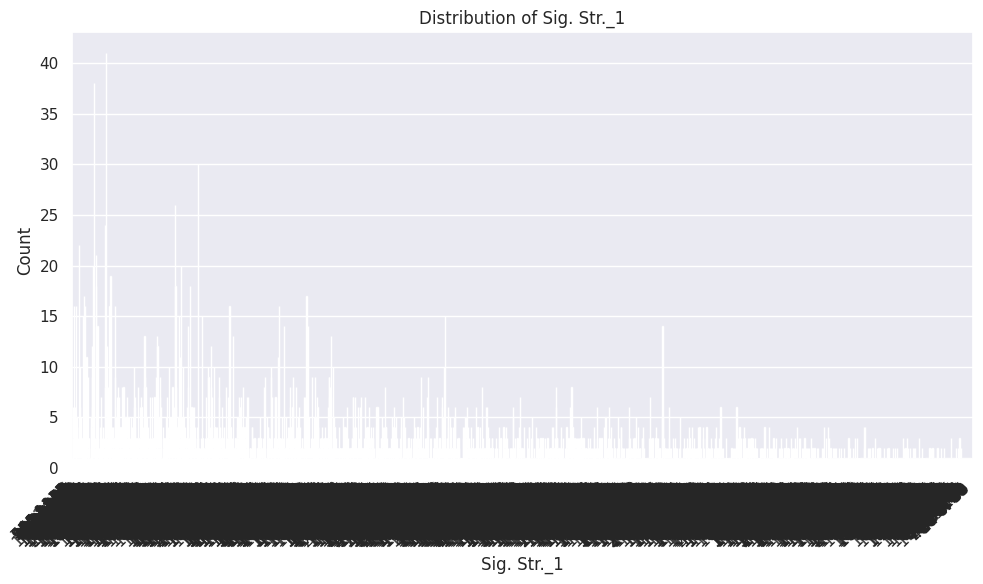

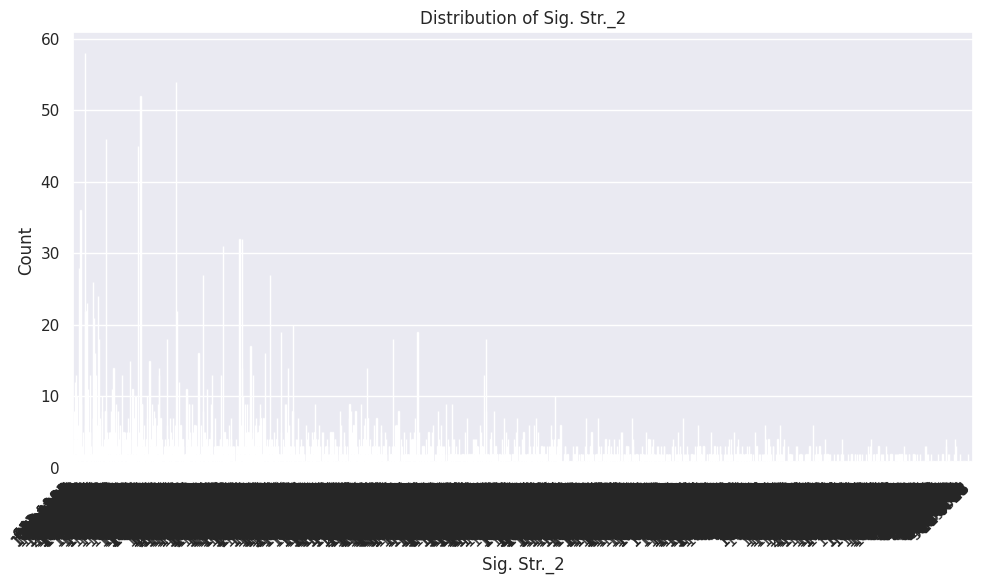

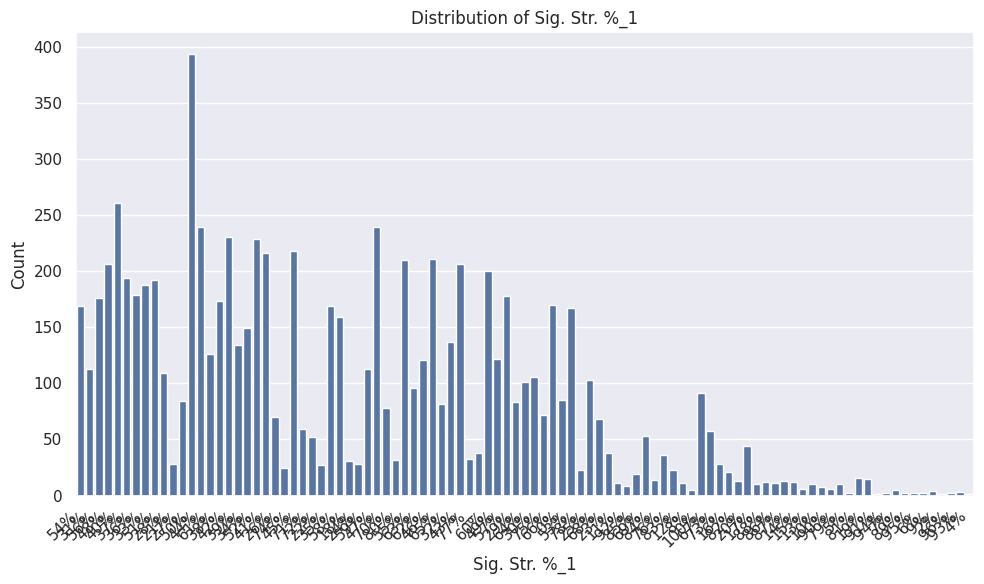

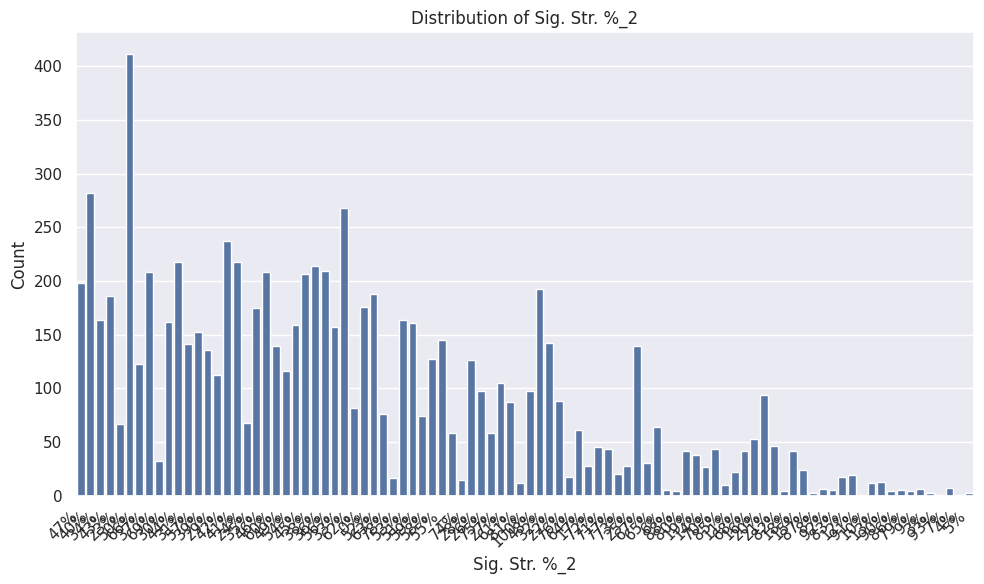

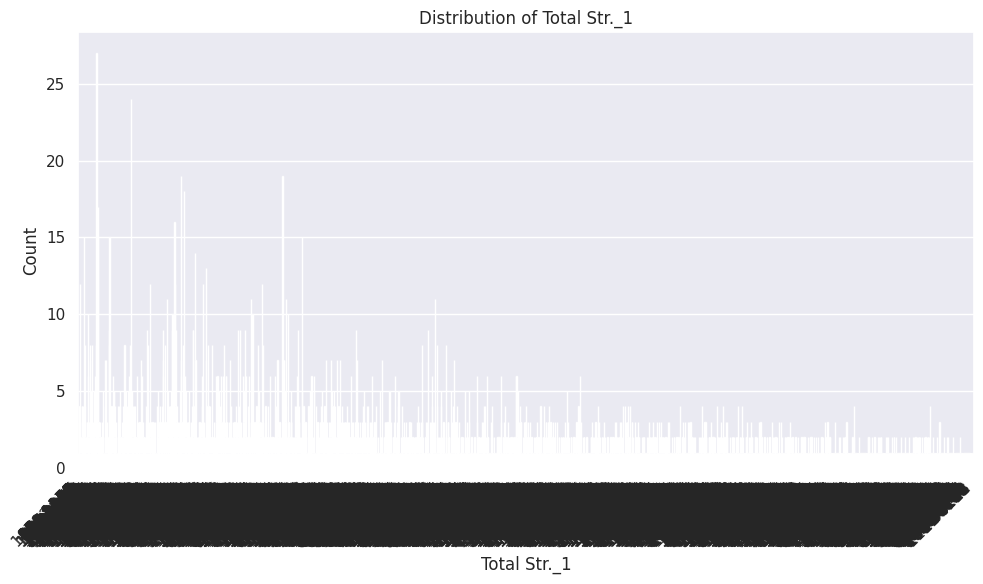

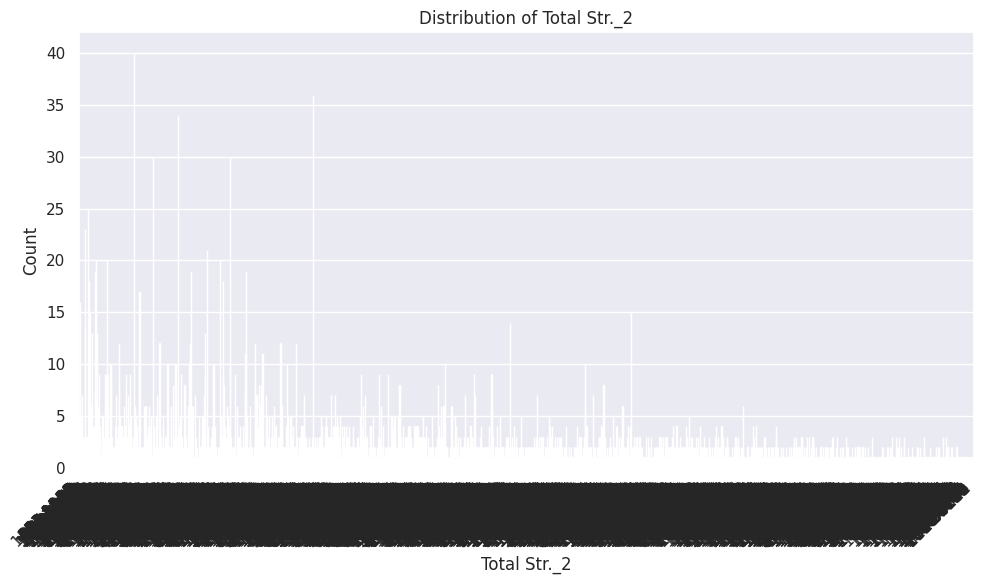

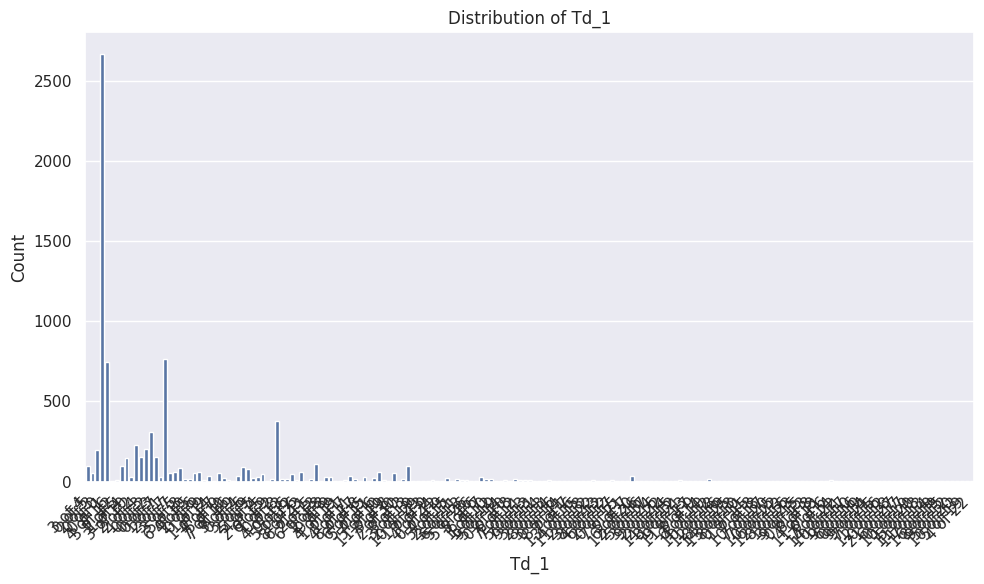

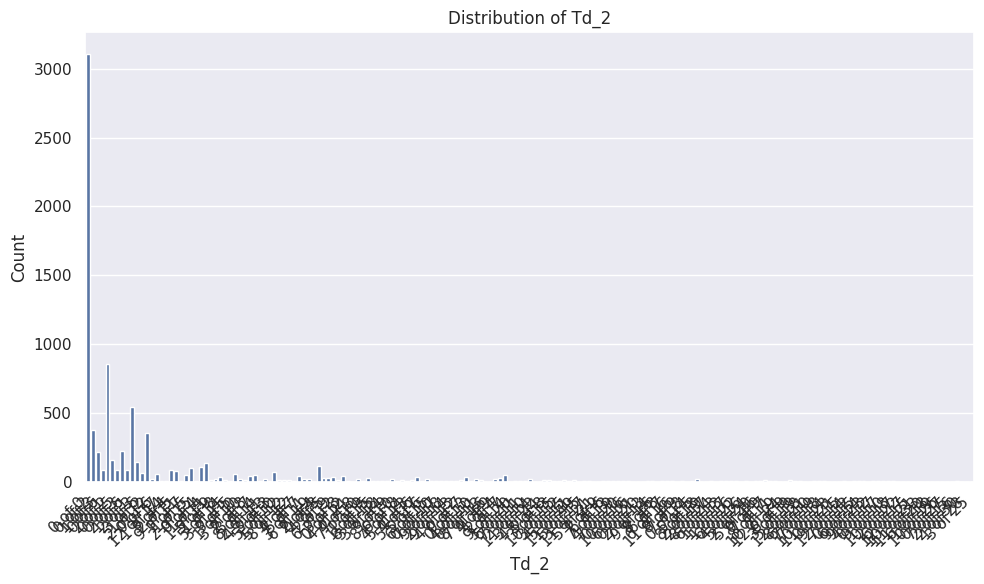

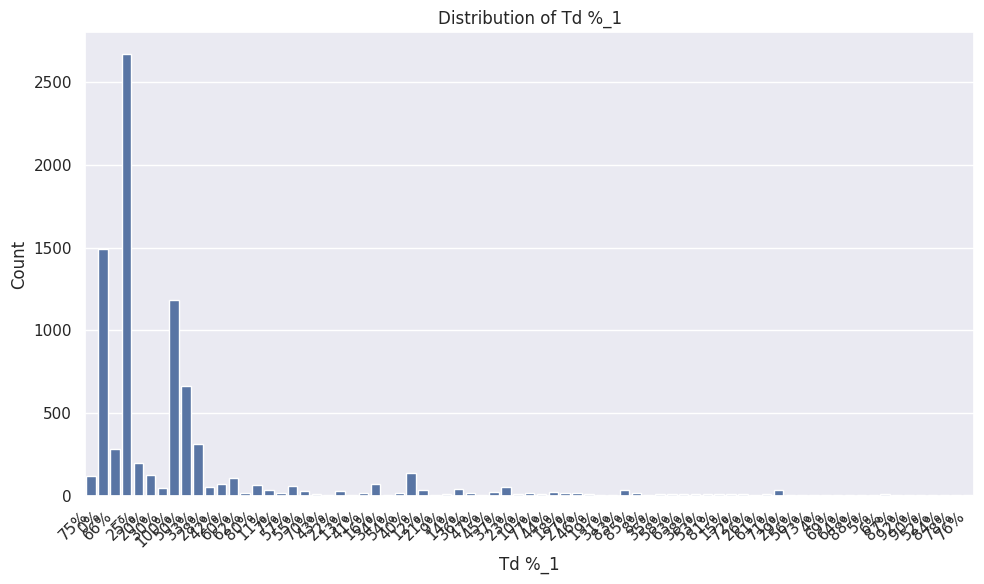

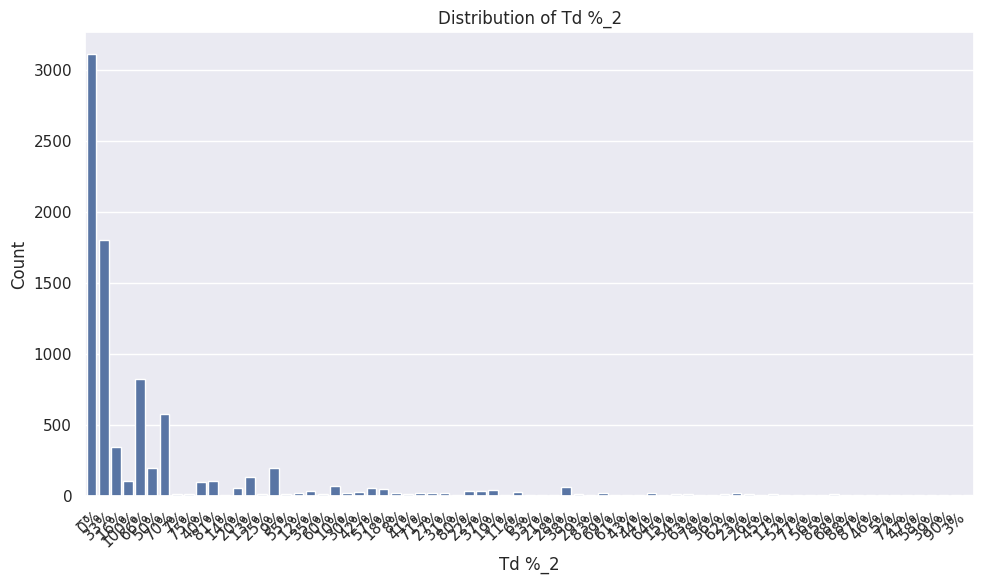

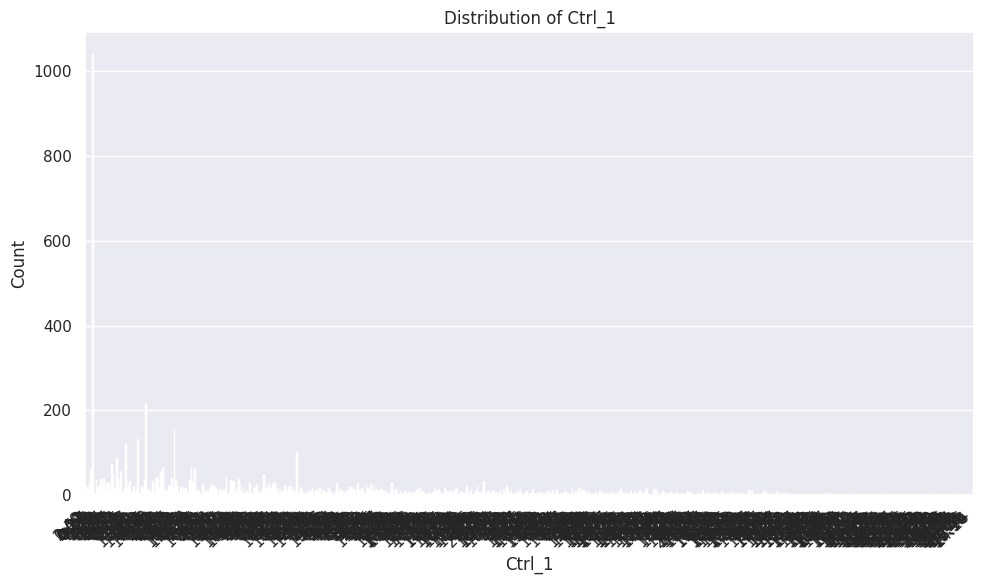

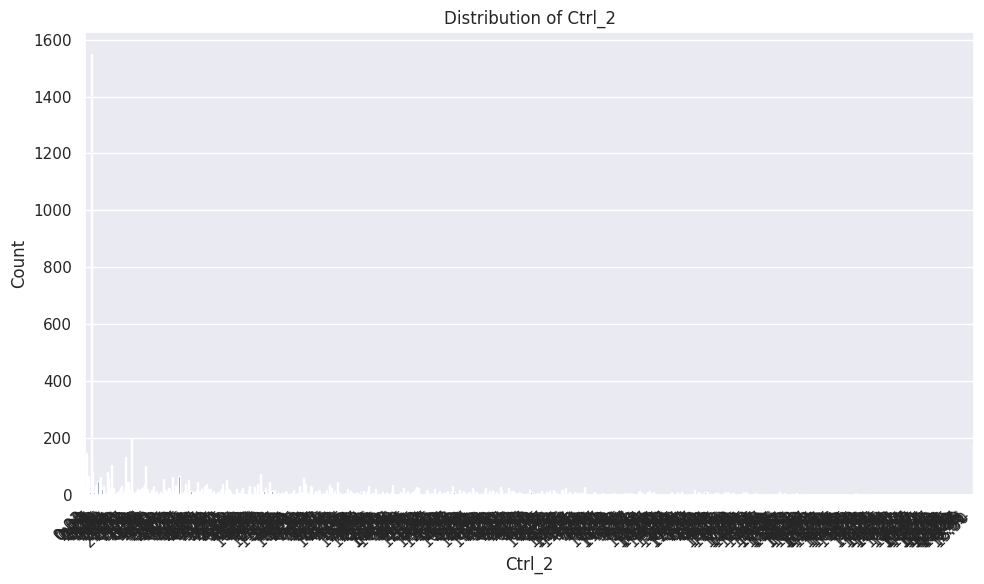

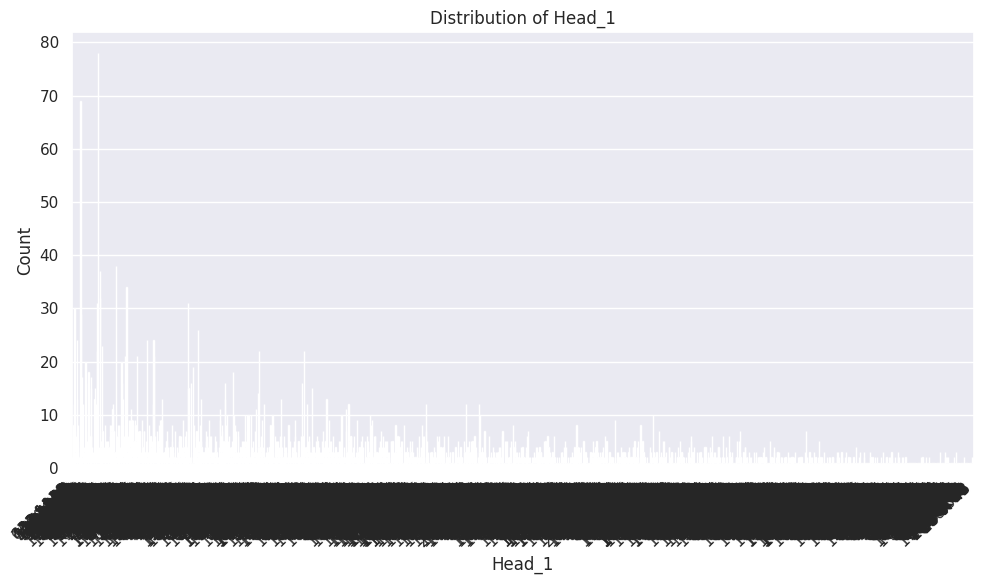

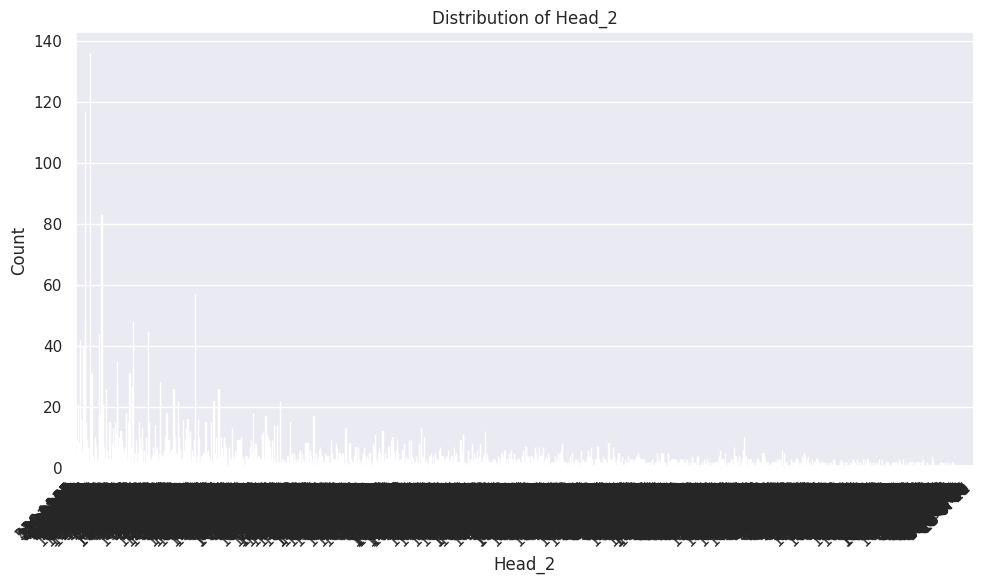

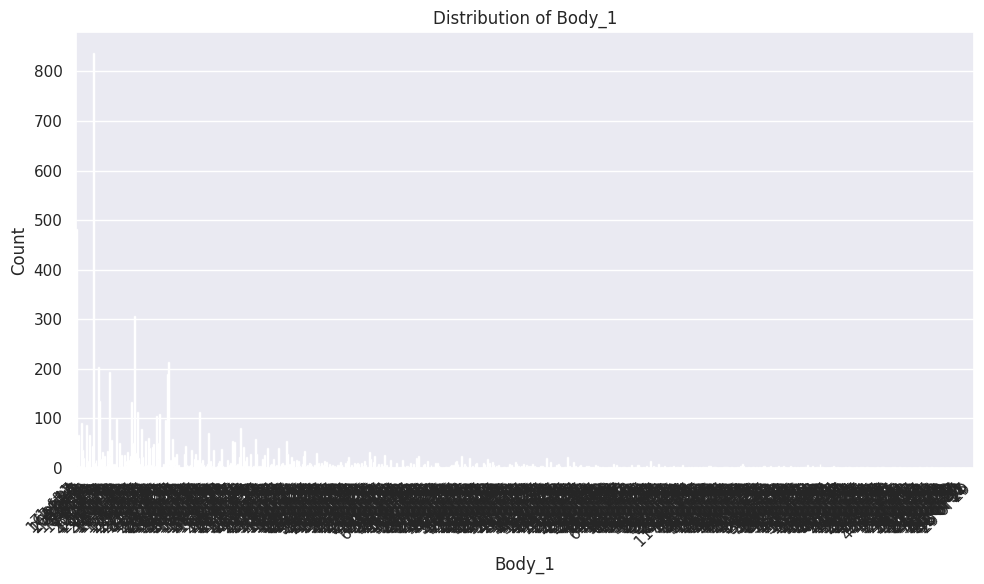

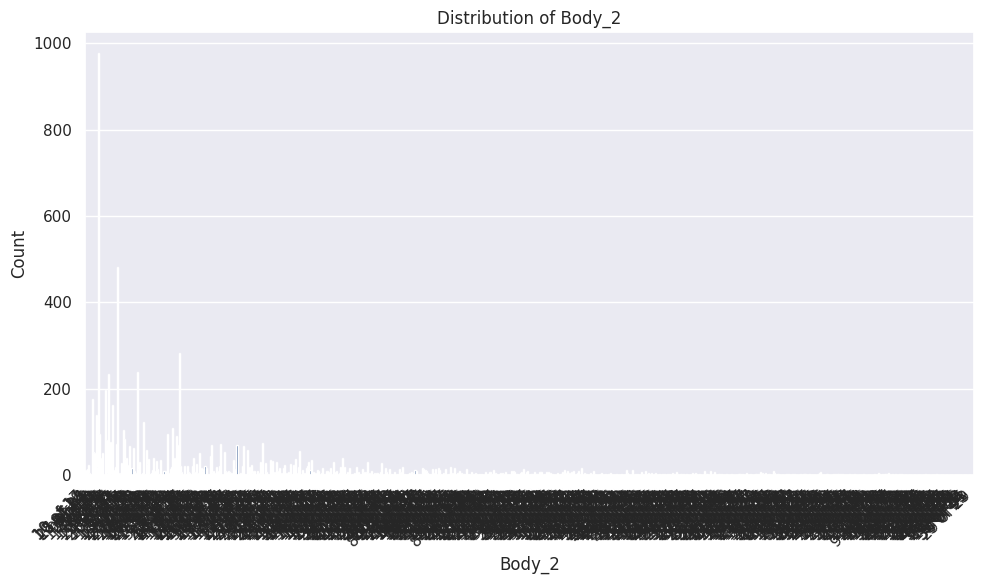

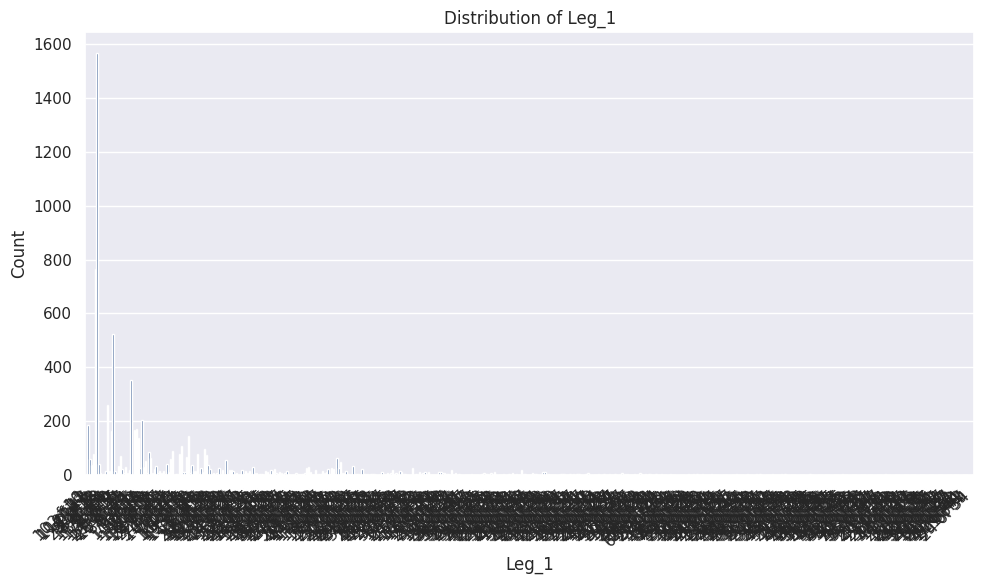

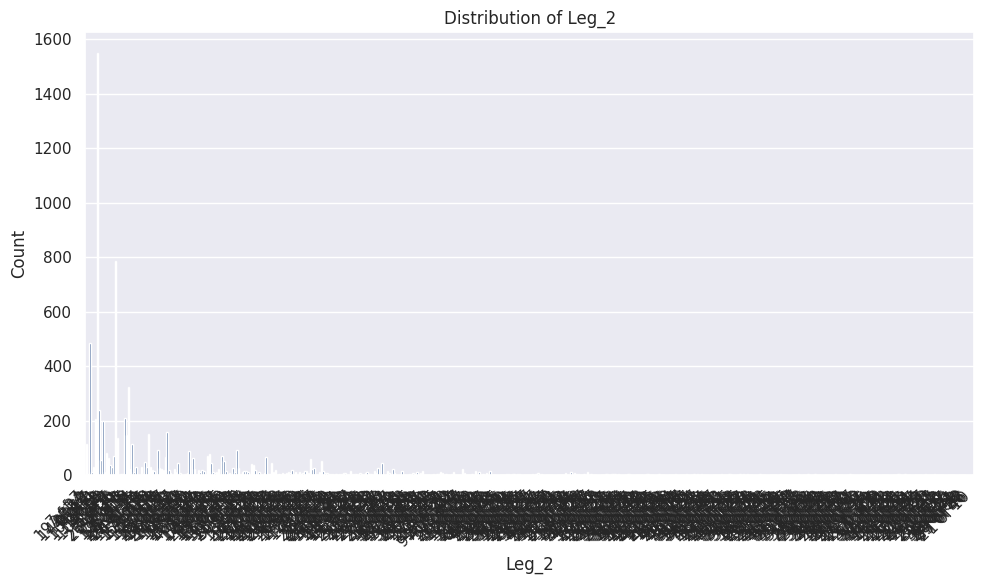

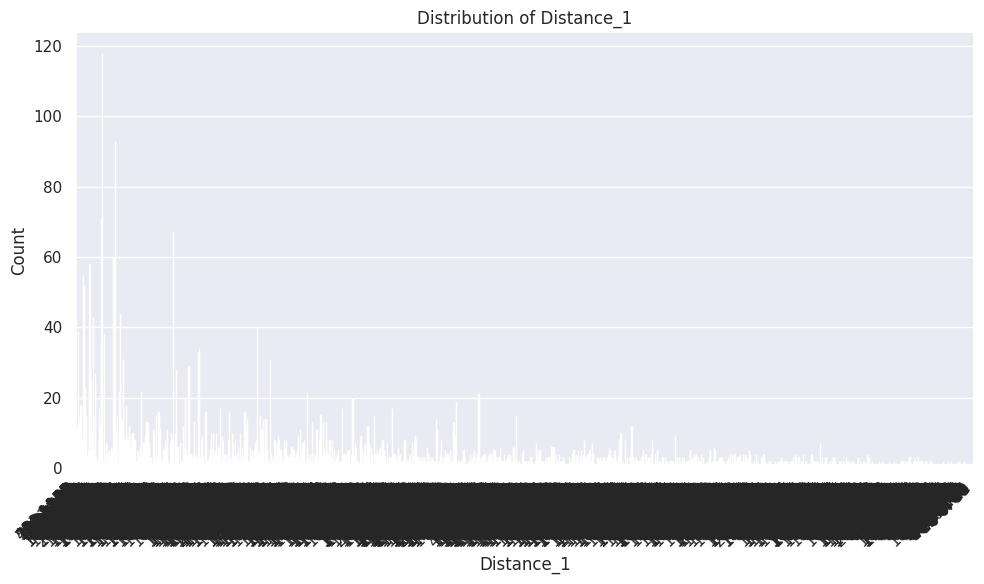

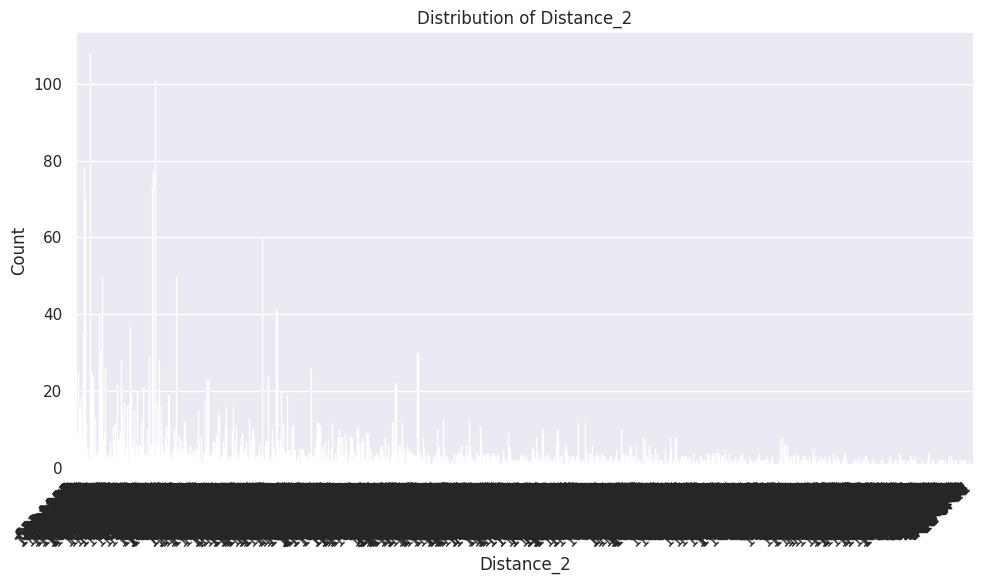

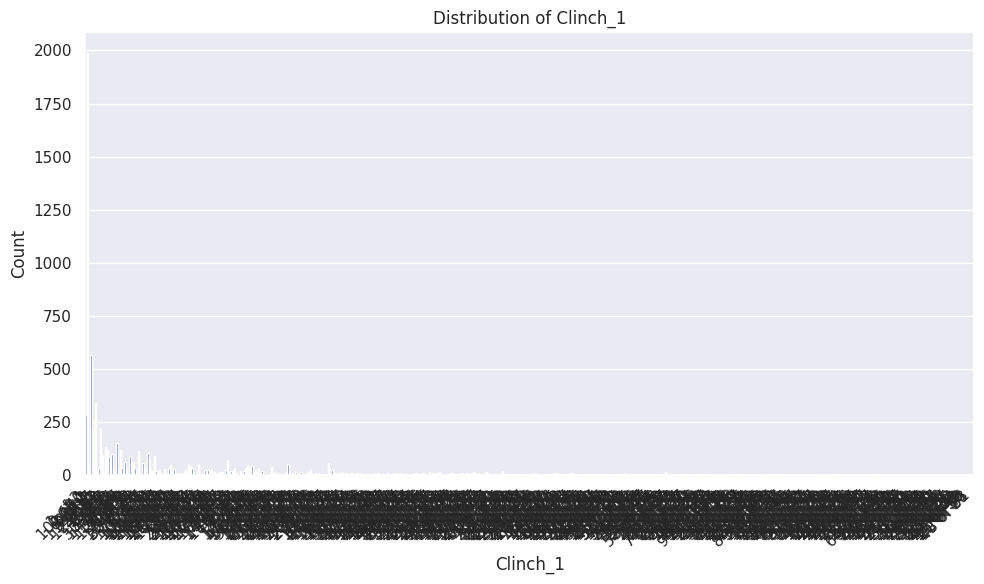

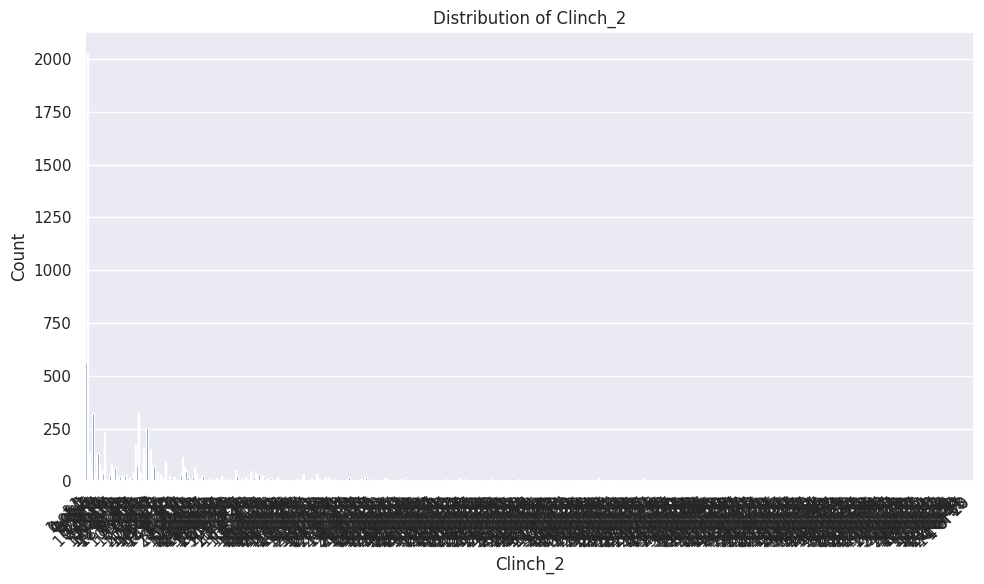

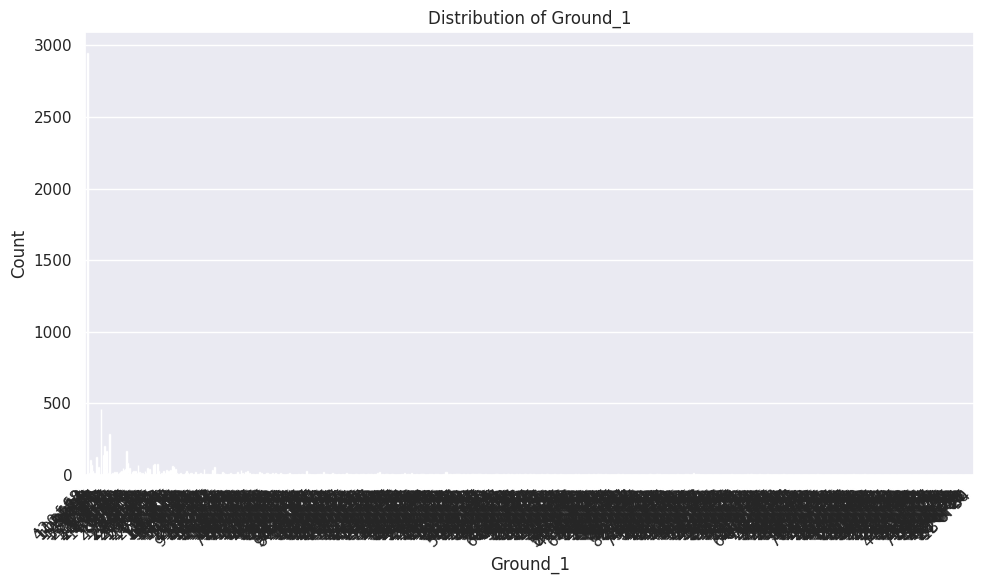

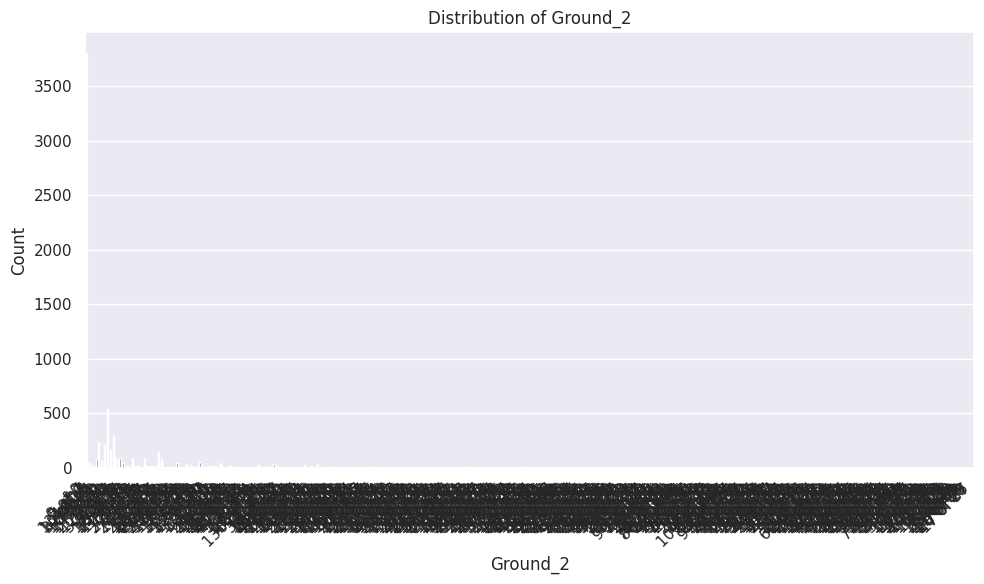

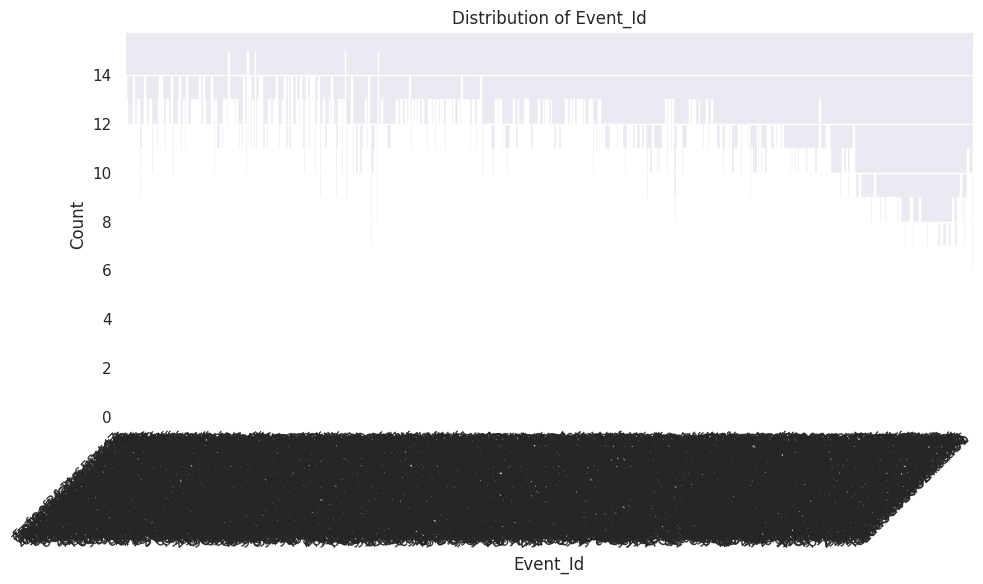

Value counts for Fight_Id:
Fight_Id
4acab67848e78327    1
de1a3734be60e6a1    1
944b929130b23c2a    1
7cbfeba85f86d1bf    1
114d2f6fcd3f6f00    1
                   ..
b53031bf4bd0a330    1
a47123ae6e048f11    1
69b31593175f77ec    1
0149e875b31e57f8    1
d14fea43712707f0    1
Name: count, Length: 8351, dtype: int64

Value counts for Result_1:
Result_1
W     5299
L     2904
NC      88
D       60
Name: count, dtype: int64

Value counts for Result_2:
Result_2
L     5299
W     2904
NC      88
D       60
Name: count, dtype: int64

Value counts for Time Format:
Time Format
3 Rnd (5-5-5)           7354
5 Rnd (5-5-5-5-5)        742
1 Rnd + OT (12-3)         88
3 Rnd + OT (5-5-5-5)      40
No Time Limit             31
1 Rnd (20)                25
1 Rnd + 2OT (15-3-3)      20
2 Rnd (5-5)               14
1 Rnd (15)                12
1 Rnd (10)                 7
1 Rnd (12)                 6
1 Rnd + OT (30-5)          3
1 Rnd + OT (15-3)          2
1 Rnd (18)                 2
1 Rnd + 2OT (24-3-3

In [40]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

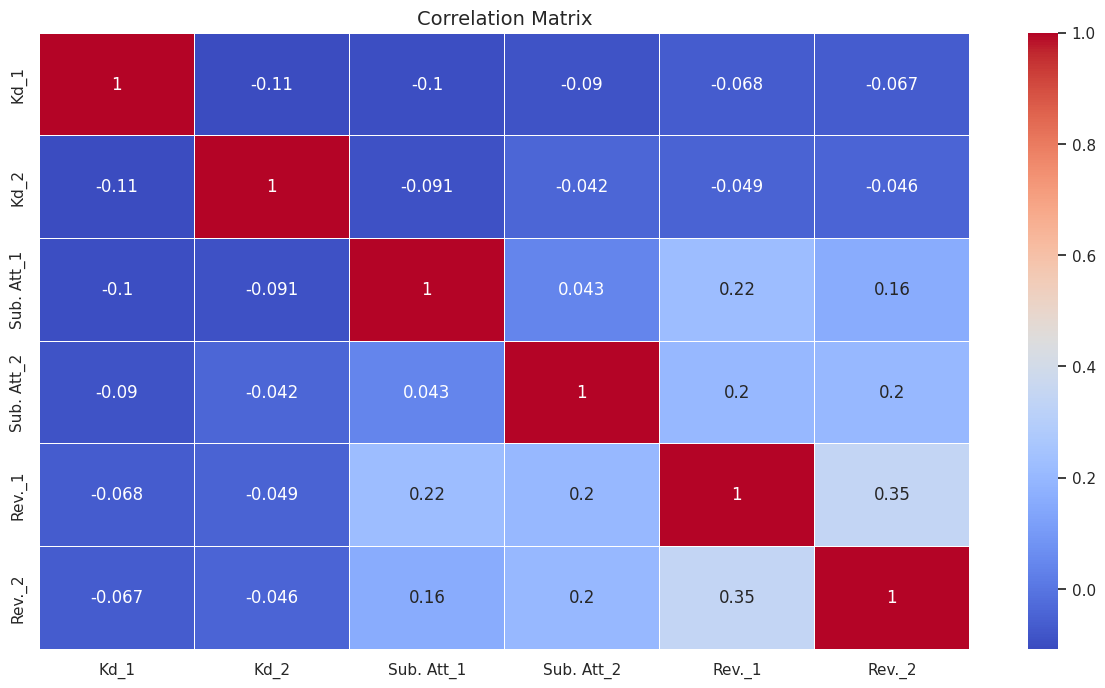

In [42]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you